# AutoEncoder on Correlation Matrices
In this notebook we train an AutoEncoder (with non-linear activations) on full correlation matrices, compress them into a latent space, reconstruct them, and evaluate reconstruction quality across different latent dimensions.

In [1]:
from pathlib import Path
import random
import warnings
import sys
import json

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import itertools


np.set_printoptions(suppress=True, precision=4)
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

## Step 1: Load Train/Val/Test Splits
Load correlation matrices and their Cholesky factors from an existing dataset folder containing `train.pt`, `val.pt`, and `test.pt` (each must include `cholesky_L`).
- Local PC: `data/processed/dataset/<DATASET_NAME>`
- Google Colab: `dataset_tesi/<DATASET_NAME>`

In [2]:
FILE_NAME = 'data_00_20'
WINDOW_SIZE = 724
STEP_SIZE = 10
DATASET_NAME = f'{FILE_NAME}_w{WINDOW_SIZE}_s{STEP_SIZE}'

if 'google.colab' in sys.modules:
    print('Ambiente rilevato: Google Colab')
    IS_COLAB = True
else:
    print('Ambiente rilevato: Locale (PC)')
    IS_COLAB = False

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    base_dir = Path('/content/drive/MyDrive/dataset_tesi')
else:
    project_root = Path.cwd().resolve().parent
    base_dir = project_root / 'data' / 'processed' / FILE_NAME / 'dataset'

dataset_dir = base_dir / DATASET_NAME

TRAIN_FILE = dataset_dir / 'train.pt'
VAL_FILE = dataset_dir / 'val.pt'
TEST_FILE = dataset_dir / 'test.pt'

for split_path in (TRAIN_FILE, VAL_FILE, TEST_FILE):
    if not split_path.exists():
        raise FileNotFoundError(
            f"Errore: Il file '{split_path.name}' non e stato trovato in: {dataset_dir.absolute()}"
        )

print(f'Dataset selezionato: {DATASET_NAME}')
print(f'Train: {TRAIN_FILE.name} | Val: {VAL_FILE.name} | Test: {TEST_FILE.name}')

Ambiente rilevato: Locale (PC)
Dataset selezionato: data_00_20_w724_s10
Train: train.pt | Val: val.pt | Test: test.pt


In [3]:
def load_dataset_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')

    if isinstance(payload, dict):
        corr_tensor = payload.get('corr_tensor', None)
        # --- MODIFICA: Estrazione del tensore di Cholesky ---
        chol_tensor = payload.get('chol_tensor', None)
        meta = {k: v for k, v in payload.items() if k not in ('corr_tensor', 'chol_tensor')}
    elif isinstance(payload, torch.Tensor):
        corr_tensor = payload
        chol_tensor = None
        meta = {}
    else:
        raise TypeError(f'Unsupported .pt format: {type(payload)}')
    
    # --- MODIFICA: Controllo presenza del tensore di Cholesky ---
    if chol_tensor is None:
        raise KeyError('chol_tensor key not found in .pt file. Assicurati di aver generato il dataset con il nuovo script.')

    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')
        
    if chol_tensor.ndim != 3 or chol_tensor.shape[1] != chol_tensor.shape[2]:
        raise ValueError(f'Invalid shape for chol_tensor: {chol_tensor.shape}')

    # Restituiamo entrambi i tensori
    return corr_tensor.float(), chol_tensor.float(), meta

# --- MODIFICA: Assegnazione multipla per accogliere chol_tensor ---
train_corr, train_chol, train_meta = load_dataset_payload(TRAIN_FILE)
val_corr, val_chol, val_meta = load_dataset_payload(VAL_FILE)
test_corr, test_chol, test_meta = load_dataset_payload(TEST_FILE)

if train_chol.shape[1:] != test_chol.shape[1:]:
    raise ValueError(f'Train/test asset dims mismatch: {train_chol.shape} vs {test_chol.shape}')
if val_chol.shape[1:] != train_chol.shape[1:]:
    raise ValueError(f'Val/train asset dims mismatch: {val_chol.shape} vs {train_chol.shape}')
print(f"{'='*50}")
print("SHAPES CARICATE:")
print(f"{'='*50}")
print(f"train_corr shape: {str(tuple(train_corr.shape)):<15} | train_chol shape: {tuple(train_chol.shape)}")
print(f"val_corr shape:   {str(tuple(val_corr.shape)):<15} | val_chol shape:   {tuple(val_chol.shape)}")
print(f"test_corr shape:  {str(tuple(test_corr.shape)):<15} | test_chol shape:  {tuple(test_chol.shape)}")

SHAPES CARICATE:
train_corr shape: (288, 362, 362) | train_chol shape: (288, 362, 362)
val_corr shape:   (82, 362, 362)  | val_chol shape:   (82, 362, 362)
test_corr shape:  (42, 362, 362)  | test_chol shape:  (42, 362, 362)


## Step 2: Prepare Matrices from Existing Splits
Use the lower-triangular Cholesky factors as input.
Each matrix is flattened to a vector of length N*(N+1)/2.
Train/val/test come directly from the loaded split files (no random split in notebook).

In [4]:
# --- MODIFICA: Usiamo i tensori di Cholesky (train_chol, val_chol, test_chol) ---
train_chol_np = train_chol.numpy().astype(np.float32)
val_chol_np = val_chol.numpy().astype(np.float32)
test_chol_np = test_chol.numpy().astype(np.float32)

n_train, n_assets, _ = train_chol_np.shape
n_val = val_chol_np.shape[0]
n_test = test_chol_np.shape[0]
n_matrices = n_train + n_val + n_test

# --- MODIFICA CHIAVE: k=0 per INCLUDERE la diagonale principale ---
tril_idx = np.tril_indices(n_assets, k=0)
n_features = len(tril_idx[0])

x_train = torch.from_numpy(train_chol_np[:, tril_idx[0], tril_idx[1]])
x_val = torch.from_numpy(val_chol_np[:, tril_idx[0], tril_idx[1]])
x_test = torch.from_numpy(test_chol_np[:, tril_idx[0], tril_idx[1]])

# --- STANDARDIZZAZIONE (Z-score normalization) ---
# La logica di standardizzazione rimane identica: è perfetto applicarla ai fattori di Cholesky

# 1. Calcola media e deviazione standard SOLO sul training set
train_mean = x_train.mean(dim=0)
train_std = x_train.std(dim=0)

epsilon = 1e-8
train_std = train_std + epsilon

# 2. Applica la normalizzazione a tutti e tre gli split 
x_train_norm = (x_train - train_mean) / train_std
x_val_norm = (x_val - train_mean) / train_std
x_test_norm = (x_test - train_mean) / train_std

print("\n--- Statistiche di Normalizzazione ---")
print(f'Train Mean shape: {tuple(train_mean.shape)}')
print(f'Train Std shape:  {tuple(train_std.shape)}')
print(f'x_train_norm mean (approx 0): {x_train_norm.mean().item():.4f}')
print(f'x_train_norm std  (approx 1): {x_train_norm.std().item():.4f}')

x_train = x_train_norm.float()
x_val = x_val_norm.float()
x_test = x_test_norm.float()

VAL_FRACTION = n_val / n_matrices
TEST_FRACTION = n_test / n_matrices

print(f'\nNumber of matrices: {n_matrices}')
print(f'Matrix shape: ({n_assets}, {n_assets})')
print(f'Flattened input size (n_features): {n_features}') # <-- Questo ora sarà 65703
print(f'Train size: {n_train} | Val size: {n_val} | Test size: {n_test}')


--- Statistiche di Normalizzazione ---
Train Mean shape: (65703,)
Train Std shape:  (65703,)
x_train_norm mean (approx 0): -0.0000
x_train_norm std  (approx 1): 0.9983

Number of matrices: 412
Matrix shape: (362, 362)
Flattened input size (n_features): 65703
Train size: 288 | Val size: 82 | Test size: 42


## Step 3: Define an AutoEncoder
- hidden_dims = None -> linear AE
- hidden_dims = [...] -> AE (ReLU + dropout)

In [5]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int], latent_dim: int):
        super().__init__()

        # Encoder
        enc_layers = []
        prev = input_dim
        for h in hidden_dims:
            enc_layers.append(nn.Linear(prev, h))
            enc_layers.append(nn.LeakyReLU(0.01))
            prev = h
        self.encoder = nn.Sequential(*enc_layers)

        self.fc_mu = nn.Linear(prev, latent_dim)
        self.fc_logvar = nn.Linear(prev, latent_dim)

        # Decoder
        dec_layers = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            dec_layers.append(nn.Linear(prev, h))
            dec_layers.append(nn.LeakyReLU(0.01))
            prev = h
        dec_layers.append(nn.Linear(prev, input_dim))
        #dec_layers.append(nn.Tanh())
        self.decoder = nn.Sequential(*dec_layers)

    def encode(self, x: torch.Tensor):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        sample = mu + (eps * std)
        return sample

    def decode(self, z: torch.Tensor):
        return self.decoder(z)

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encode(x)
        if self.training:
            # Durante l'addestramento (model.train()), usa il campionamento stocastico
            z = self.reparameterize(mu, logvar)
        else:
            # Durante la validazione/test (model.eval()), usa l'aspettativa esatta
            z = mu
        x_hat = self.decode(z)
        return x_hat, mu, logvar

## Step 4: Training and Evaluation Utilities
Train the model, reconstruct matrices, and compute reconstruction errors.

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def vae_loss(x_hat, orig_corr, mu, logvar, train_mean, train_std, n_assets, beta=1.0):
    batch_size = x_hat.shape[0]
    device = x_hat.device
    
    # 1. Denormalizzazione (differenziabile)
    x_hat_denorm = (x_hat * train_std) + train_mean
    
    # 2. Ricostruzione L (Fattori di Cholesky triangolari inferiori)
    L_hat = torch.zeros((batch_size, n_assets, n_assets), device=device)
    tril_idx = torch.tril_indices(row=n_assets, col=n_assets, offset=0)
    L_hat[:, tril_idx[0], tril_idx[1]] = x_hat_denorm
    
    # 3. Ricostruzione e normalizzazione della Matrice di Correlazione (PSD)
    PSD_hat = torch.bmm(L_hat, L_hat.transpose(1, 2)) # Calcolo di C = L @ L.T per garantire PSD
    
    # Estraiamo le diagonali (varianze) per normalizzare in matrice di correlazione pura
    d_hat = torch.diagonal(PSD_hat, dim1=1, dim2=2)
    d_inv_sqrt = 1.0 / torch.sqrt(torch.clamp(d_hat, min=1e-12)) # Clamp per stabilità numerica
    
    # Moltiplicazione efficiente con broadcasting: D^{-1/2} * PSD_hat * D^{-1/2}
    recon_corr = PSD_hat * d_inv_sqrt.unsqueeze(2) * d_inv_sqrt.unsqueeze(1)
    
    # Stabilizzazione esatta a 1.0 sulla diagonale
    diag_idx = torch.arange(n_assets, device=device)
    recon_corr[:, diag_idx, diag_idx] = 1.0
    
    # 4. Symmetrized KL Divergence (Divergenza di Jeffreys)
    # Aggiungiamo un piccolo ridge (jitter) per garantire la stabilità durante l'inversione
    ridge = torch.eye(n_assets, device=device) * 1e-5
    recon_corr_stable = recon_corr + ridge
    orig_corr_stable = orig_corr + ridge
    
    # Usiamo solve per risolvere i sistemi lineari A^-1 * B senza invertire esplicitamente la matrice
    term1 = torch.linalg.solve(recon_corr_stable, orig_corr_stable)
    term2 = torch.linalg.solve(orig_corr_stable, recon_corr_stable)
    
    # Calcolo della traccia batch-wise: Tr(Sigma_recon^-1 * Sigma_orig) + Tr(Sigma_orig^-1 * Sigma_recon) - 2k
    trace1 = torch.diagonal(term1, dim1=1, dim2=2).sum(dim=1)
    trace2 = torch.diagonal(term2, dim1=1, dim2=2).sum(dim=1)
    
    jeffreys_div = 0.5 * (trace1 + trace2 - 2 * n_assets)
    recon_loss = torch.mean(jeffreys_div)
    
    # 5. KL Divergence standard (per lo Spazio Latente)
    kl_per_matrix = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    kl = torch.mean(kl_per_matrix)
    
    
    total = recon_loss + beta * kl
    
    return total, recon_loss, kl

def train_VAE(
    x_train_tensor: torch.Tensor,
    orig_train_corr: torch.Tensor,  # NUOVO PARAMETRO TARGET
    x_val_tensor: torch.Tensor,
    orig_val_corr: torch.Tensor,    # NUOVO PARAMETRO TARGET
    latent_dim: int,
    n_assets: int,                  # NUOVO PARAMETRO
    train_mean: torch.Tensor,       # NUOVO PARAMETRO
    train_std: torch.Tensor,        # NUOVO PARAMETRO
    hidden_dims=None,
    epochs: int = 80,
    batch_size: int = 64,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    dropout: float = 0.02,
    seed: int = 42,
    scheduler_name: str = 'none',
    cosine_t_max: int = 80,
    cosine_eta_min: float = 1e-8,
    resume_state_dict=None,
    initial_best=None,
    beta: float = 1.0,
):
    # 1) Seed for reproducibility
    set_seed(seed)

    # 2) Model, optimizer, scheduler
    model = VAE(input_dim=x_train_tensor.shape[1], latent_dim=latent_dim, hidden_dims=hidden_dims).to(device)
    if resume_state_dict is not None:
        model.load_state_dict(resume_state_dict)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler_key = str(scheduler_name).strip().lower()
    valid_schedulers = {'none', 'cosine'}
    if scheduler_key not in valid_schedulers:
        raise ValueError(f"Invalid scheduler '{scheduler_name}'. Choose one of {sorted(valid_schedulers)}")

    scheduler = None
    if scheduler_key == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cosine_t_max, eta_min=cosine_eta_min)

    # 3) DataLoaders (ora includono i target di correlazione)
    train_loader = DataLoader(TensorDataset(x_train_tensor, orig_train_corr), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(x_val_tensor, orig_val_corr), batch_size=batch_size, shuffle=False)

    history = {
        'train_loss': [], 'train_recon': [], 'train_kl': [],
        'val_loss': [], 'val_recon': [], 'val_kl': [],
        'lr': []
    }

    # Trasferimento parametri di normalizzazione sul device corretto
    device_mean = train_mean.to(device)
    device_std = train_std.to(device)

    # 4) Initialization of best TRAINING loss
    if resume_state_dict is not None:
        if initial_best is None:
            model.eval()
            train_loss_sum = 0.0
            with torch.no_grad():
                for xb, cb in train_loader:
                    xb, cb = xb.to(device), cb.to(device)
                    x_hat, mu, logvar = model(xb)
                    loss, _, _ = vae_loss(x_hat, cb, mu, logvar, device_mean, device_std, n_assets, beta=beta)
                    train_loss_sum += loss.item() * xb.size(0)
            initial_best = train_loss_sum / len(train_loader.dataset)

        best_train = float(initial_best)
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        best_train = float('inf')
        best_state = None

    # 5) Training loop
    for epoch in range(epochs):
        model.train()
        
        train_loss_sum, train_recon_sum, train_kl_sum = 0.0, 0.0, 0.0
        current_lr = float(optimizer.param_groups[0]['lr'])

        # Ciclo con estrazione di xb (input) e cb (correlazione target)
        for xb, cb in train_loader:
            xb, cb = xb.to(device), cb.to(device)
            optimizer.zero_grad()
            
            x_hat, mu, logvar = model(xb)
            loss, recon, kl = vae_loss(x_hat, cb, mu, logvar, device_mean, device_std, n_assets, beta=beta)
            
            loss.backward()
            
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=500.0)
            #print(f"Batch Gradient Norm: {grad_norm.item():.2f}")
            optimizer.step()
            
            train_loss_sum += loss.item() * xb.size(0)
            train_recon_sum += recon.item() * xb.size(0)
            train_kl_sum += kl.item() * xb.size(0)

        train_loss = train_loss_sum / len(train_loader.dataset)
        train_recon = train_recon_sum / len(train_loader.dataset)
        train_kl = train_kl_sum / len(train_loader.dataset)

        model.eval()
        val_loss_sum, val_recon_sum, val_kl_sum = 0.0, 0.0, 0.0
        
        with torch.no_grad():
            for xb, cb in val_loader:
                xb, cb = xb.to(device), cb.to(device)
                x_hat, mu, logvar = model(xb)
                loss, recon, kl = vae_loss(x_hat, cb, mu, logvar, device_mean, device_std, n_assets, beta=beta)
                
                val_loss_sum += loss.item() * xb.size(0)
                val_recon_sum += recon.item() * xb.size(0)
                val_kl_sum += kl.item() * xb.size(0)

        val_loss = val_loss_sum / len(val_loader.dataset)
        val_recon = val_recon_sum / len(val_loader.dataset)
        val_kl = val_kl_sum / len(val_loader.dataset)
        
        history['train_loss'].append(train_loss)
        history['train_recon'].append(train_recon)
        history['train_kl'].append(train_kl)
        history['val_loss'].append(val_loss)
        history['val_recon'].append(val_recon)
        history['val_kl'].append(val_kl)
        history['lr'].append(current_lr)

        if scheduler is not None:
            if scheduler_key == 'plateau':
                scheduler.step(train_loss)
            else:
                scheduler.step()

        if val_loss < best_train:
            best_train = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f'Epoch {epoch + 1:02d}/{epochs} | lr={current_lr:.2e} | Train Loss={train_loss:.6f} (Recon={train_recon:.6f}, KL={train_kl:.6f}) | Val Loss={val_loss:.6f} (Recon={val_recon:.6f}, KL={val_kl:.6f})')

    if best_state is None:
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)

    return model, history, best_train


def reconstruct_matrices(
    model: nn.Module,
    x_tensor: torch.Tensor,
    n_assets: int,
    train_mean: torch.Tensor,  
    train_std: torch.Tensor,   
    batch_size: int = 4,
    device: str = 'cuda' # Assicurati che device sia definito
):
    model.eval()
    loader = DataLoader(TensorDataset(x_tensor), batch_size=batch_size, shuffle=False)
    
    outputs = []
    latent_points = [] # Lista per accumulare i punti latenti

    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            
            # Estraiamo x_hat e mu dal VAE
            x_hat, mu, _ = model(xb) 
            
            pred = x_hat.cpu().numpy()
            latent = mu.cpu().numpy() 
            
            outputs.append(pred)
            latent_points.append(latent) 

    # 1. Array flattenato predetto pre-denormalizzazione (Fattori di Cholesky)
    recon_flat = np.concatenate(outputs, axis=0).astype(np.float32)
    n_samples = recon_flat.shape[0]

    # Concatenazione dei punti latenti in un unico array (n_samples, latent_dim)
    latent_flat = np.concatenate(latent_points, axis=0).astype(np.float32)

    # --- DENORMALIZZAZIONE ---
    mean_np = train_mean.cpu().numpy() if isinstance(train_mean, torch.Tensor) else train_mean
    std_np = train_std.cpu().numpy() if isinstance(train_std, torch.Tensor) else train_std
    
    recon_flat = (recon_flat * std_np) + mean_np
    # -------------------------

    # 2. Inizializza il batch di matrici quadrate L (Cholesky factor) riempite di zeri
    recon_L = np.zeros((n_samples, n_assets, n_assets), dtype=np.float32)

    # 3. Estrai indici del triangolo inferiore INCLUSA la diagonale (k=0)
    tril_idx = np.tril_indices(n_assets, k=0)

    # 4. Inserisci i valori predetti per formare le matrici triangolari inferiori
    recon_L[:, tril_idx[0], tril_idx[1]] = recon_flat

    # 5. RICOSTRUZIONE E NORMALIZZAZIONE DELLA CORRELAZIONE (Garantisce PSD)
    # Calcolo di C = L @ L.T 
    recon_PSD = recon_L @ np.transpose(recon_L, axes=(0, 2, 1))

    # Estraiamo la diagonale di ogni matrice (le varianze)
    d = np.diagonal(recon_PSD, axis1=1, axis2=2)
    
    # Calcoliamo 1 / sqrt(d) gestendo eventuali divisioni per zero
    d_inv_sqrt = 1.0 / np.sqrt(np.maximum(d, 1e-12))
    
    # Creiamo matrici diagonali per la normalizzazione
    D_inv_sqrt = np.zeros_like(recon_PSD)
    diag_idx = np.arange(n_assets)
    D_inv_sqrt[:, diag_idx, diag_idx] = d_inv_sqrt
    
    # Normalizzazione: Corr = D_inv_sqrt @ PSD @ D_inv_sqrt
    recon_corr = D_inv_sqrt @ recon_PSD @ D_inv_sqrt
    
    # Pulizia floating point finale e ripristino esatto della diagonale
    recon_corr = np.clip(recon_corr, -1.0, 1.0)
    recon_corr[:, diag_idx, diag_idx] = 1.0

    return {
        'recon_corr': recon_corr,
        'recon_chol': recon_L,       # Utile se ti serve ispezionare L
        'latent_points': latent_flat # Array dei punti nello spazio latente (mu)
    }

def reconstruction_errors(original: np.ndarray, reconstructed: np.ndarray):
    diff = original - reconstructed

    mse_per_matrix = np.mean(diff ** 2, axis=(1, 2))
    mae_per_matrix = np.mean(np.abs(diff), axis=(1, 2))
    fro_per_matrix = np.linalg.norm(diff, ord='fro', axis=(1, 2))

    summary = pd.DataFrame({
        'MSE': mse_per_matrix,
        'MAE': mae_per_matrix,
        'Frobenius': fro_per_matrix,
    })

    stats = summary.agg(['mean', 'std', 'min', 'median', 'max']).T
    return summary, stats

Device: cuda


In [7]:
if torch.cuda.is_available():
    # 1. Nome della GPU
    print(f"Modello GPU: {torch.cuda.get_device_name(0)}")
    
    # 2. Capacità computazionale (Compute Capability)
    # Indica la generazione dell'architettura (es. 8.9 per le RTX 4000)
    major, minor = torch.cuda.get_device_capability(0)
    print(f"Compute Capability: {major}.{minor}")
    
    # 3. Gestione Memoria (in GB)
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    reserved_memory = torch.cuda.memory_reserved(0) / 1e9
    allocated_memory = torch.cuda.memory_allocated(0) / 1e9
    
    print(f"Memoria Totale: {total_memory:.2f} GB")
    print(f"Memoria Riservata: {reserved_memory:.2f} GB")
    print(f"Memoria in uso: {allocated_memory:.2f} GB")
    
    # 4. Numero di Multiprocetori Streaming (SM)
    # Più alto è il numero, maggiore è il parallelismo
    sm_count = torch.cuda.get_device_properties(0).multi_processor_count
    print(f"Numero di Streaming Multiprocessors: {sm_count}")

else:
    print("GPU non disponibile.")

Modello GPU: NVIDIA GeForce RTX 3060
Compute Capability: 8.6
Memoria Totale: 12.88 GB
Memoria Riservata: 0.00 GB
Memoria in uso: 0.00 GB
Numero di Streaming Multiprocessors: 28


## Step 5: Train One Configuration and Reconstruct Matrices
Train one AE configuration, reconstruct all matrices, and inspect training losses.

In [8]:
SEED = 42
MODEL_TYPE = 'VAE'
LATENT_DIM = 20

RUN = MODEL_TYPE + "_" + str(LATENT_DIM) + "dim_" + "cholesky_06_loss"
RESUME_TRAINING = False
RESUME_RUN = MODEL_TYPE + "_" + str(LATENT_DIM) + "dim_" + "cholesky_01"

if IS_COLAB:
    RESUME_MODEL_PATH = f"best_models_tesi/{MODEL_TYPE}/{RESUME_RUN}/best_model.pt"
else:
    RESUME_MODEL_PATH = f"models/{DATASET_NAME}/{MODEL_TYPE}/{RESUME_RUN}/best_model.pt"

BETA = 1
EPOCHS = 1000
BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-5
# Scheduler selector: 'none', 'cosine'
SCHEDULER_NAME = 'cosine'
# CosineAnnealingLR params
COSINE_T_MAX = EPOCHS
COSINE_ETA_MIN = 1e-6

# Hidden layers for the VAE encoder (decoder is mirrored automatically).
# If you resume from an old checkpoint, this must match that checkpoint architecture.
HIDDEN_DIMS = [2048, 1024, 512]

if IS_COLAB:
    run_dir = Path(f'/content/drive/MyDrive/best_models_tesi/{MODEL_TYPE}')
else:
    run_dir = project_root / 'models'/ DATASET_NAME / MODEL_TYPE

run_output_dir = run_dir / RUN
run_output_dir.mkdir(parents=True, exist_ok=True)
print(f'Results directory: {run_output_dir}')
print(f'Resume training: {RESUME_TRAINING}')

Results directory: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\VAE\VAE_20dim_cholesky_06_loss
Resume training: False


In [9]:
resume_state_dict = None
resume_initial_val = None
resume_source_path = None

# Resume logic: load checkpoint, check compatibility, extract state dict and initial val loss if available
if RESUME_TRAINING:
    if RESUME_MODEL_PATH is None:
        raise ValueError('RESUME_TRAINING=True but RESUME_MODEL_PATH is None.')

    resume_source_path = Path(RESUME_MODEL_PATH)
    if not resume_source_path.is_absolute():
        if IS_COLAB:
            resume_source_path = Path('/content/drive/MyDrive') / resume_source_path
        else:
            resume_source_path = project_root / resume_source_path
    resume_source_path = resume_source_path.resolve()

    if not resume_source_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {resume_source_path}')

    checkpoint = torch.load(resume_source_path, map_location=device)
    state_dict = checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint
    
    probe_model = VAE(
        input_dim=x_train.shape[1],
        latent_dim=LATENT_DIM,
        hidden_dims=HIDDEN_DIMS,
    )
    current_shapes = {k: tuple(v.shape) for k, v in probe_model.state_dict().items()}
    loaded_shapes = {k: tuple(v.shape) for k, v in state_dict.items()}

    missing_keys = [k for k in current_shapes.keys() if k not in loaded_shapes]
    unexpected_keys = [k for k in loaded_shapes.keys() if k not in current_shapes]
    shape_mismatches = [
        (k, loaded_shapes[k], current_shapes[k])
        for k in current_shapes.keys()
        if k in loaded_shapes and loaded_shapes[k] != current_shapes[k]
    ]

    if missing_keys or shape_mismatches or unexpected_keys:
        suggested_hidden = []
        # Cerchiamo tutti i pesi dei layer lineari nell'encoder
        for key, weight in state_dict.items():
            if key.startswith('encoder.') and key.endswith('.weight'):
                # Escludiamo il primo strato (input_dim -> hidden[0])
                if weight.shape[1] == x_train.shape[1]:
                    continue
                suggested_hidden.append(int(weight.shape[0]))

        # L'ultimo elemento trovato sara il latent_dim
        if suggested_hidden:
            ckpt_latent_dim = suggested_hidden[-1]
            ckpt_hidden_dims = suggested_hidden[:-1]
            hint = (
                f'Checkpoint expects latent_dim={ckpt_latent_dim}, '
                f'hidden_dims={ckpt_hidden_dims}. '
                'Set these values to match before resuming, or start a new run without resume.'
            )
        else:
            hint = 'Checkpoint architecture could not be inferred. Use a checkpoint saved with the same model architecture.'

        details = []
        if missing_keys:
            details.append(f'Missing keys (first 5): {missing_keys[:5]}')
        if unexpected_keys:
            details.append(f'Unexpected keys (first 5): {unexpected_keys[:5]}')
        if shape_mismatches:
            k, loaded_shape, current_shape = shape_mismatches[0]
            details.append(f'Shape mismatch example: {k} loaded={loaded_shape}, current={current_shape}')

        raise RuntimeError(
            'Incompatible checkpoint for current VAE architecture. ' + hint + (' | ' + ' ; '.join(details) if details else '')
        )

    resume_state_dict = state_dict
    if isinstance(checkpoint, dict) and 'best_val_loss' in checkpoint:
        resume_initial_val = float(checkpoint['best_val_loss'])

    if resume_initial_val is None:
        temp_model = VAE(
            input_dim=x_train.shape[1],
            latent_dim=LATENT_DIM,
            hidden_dims=HIDDEN_DIMS,
        ).to(device)
        temp_model.load_state_dict(resume_state_dict)
        temp_model.eval()

        val_loader = DataLoader(TensorDataset(x_val), batch_size=BATCH_SIZE, shuffle=False)
        val_loss_sum = 0.0
        with torch.no_grad():
            for (xb,) in val_loader:
                xb = xb.to(device)
                
                # 3. MODIFICA: Disimballiamo l'output del VAE e calcoliamo la vae_loss
                x_hat, mu, logvar = temp_model(xb)
                loss, _, _ = vae_loss(x_hat, xb, mu, logvar, beta=BETA)
                
                val_loss_sum += loss.item() * xb.size(0)
        resume_initial_val = val_loss_sum / len(val_loader.dataset)

    print(f'Loaded checkpoint: {resume_source_path}')
    print(f'Checkpoint validation Loss (baseline for resume): {resume_initial_val:.6f}')

# Train the model (or resume training if applicable)
model, history, best_val = train_VAE(
    x_train_tensor=x_train,
    orig_train_corr=train_corr, # Matrice originale 
    x_val_tensor=x_val,
    orig_val_corr=val_corr,     # Matrice originale 
    latent_dim=LATENT_DIM,
    n_assets=n_assets,          # Parametro numerico
    train_mean=train_mean,      # Statistica d'appoggio per denormalizzazione
    train_std=train_std,        # Statistica d'appoggio per denormalizzazione
    hidden_dims=HIDDEN_DIMS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    seed=SEED,
    scheduler_name=SCHEDULER_NAME,
    cosine_t_max=COSINE_T_MAX,
    cosine_eta_min=COSINE_ETA_MIN,
    resume_state_dict=resume_state_dict,
    initial_best=resume_initial_val,
    beta=BETA,
)


# --- SALVATAGGIO DEL MODELLO ---
best_model_path = run_output_dir / 'best_model.pt'
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'model_config': {
            'input_dim': int(x_train.shape[1]),
            'latent_dim': int(LATENT_DIM),
            'hidden_dims': HIDDEN_DIMS,
            'epochs': int(EPOCHS),
            'batch_size': int(BATCH_SIZE),
            'lr': float(LR),
            'weight_decay': float(WEIGHT_DECAY),
            'seed': int(SEED),
            'scheduler': {
                'key': str(SCHEDULER_NAME).strip().lower(),
            },
            'beta': float(BETA),
        },
        'best_val_loss': float(best_val),
    },
    best_model_path,
)
print(f'Saved best model: {best_model_path}')
print(f'Best validation loss: {best_val:.6f}')

Epoch 01/1000 | lr=1.00e-03 | Train Loss=445.342594 (Recon=258.813956, KL=186.528637) | Val Loss=232.391827 (Recon=209.665797, KL=22.726031)
Epoch 02/1000 | lr=1.00e-03 | Train Loss=230.256088 (Recon=210.840159, KL=19.415925) | Val Loss=220.458192 (Recon=201.924400, KL=18.533790)
Epoch 03/1000 | lr=1.00e-03 | Train Loss=199.982766 (Recon=178.406884, KL=21.575881) | Val Loss=172.134261 (Recon=152.008168, KL=20.126088)
Epoch 04/1000 | lr=1.00e-03 | Train Loss=155.902996 (Recon=136.119083, KL=19.783914) | Val Loss=137.775454 (Recon=122.246568, KL=15.528881)
Epoch 05/1000 | lr=1.00e-03 | Train Loss=132.594242 (Recon=115.142520, KL=17.451722) | Val Loss=124.926824 (Recon=108.403796, KL=16.523026)
Epoch 06/1000 | lr=1.00e-03 | Train Loss=121.756649 (Recon=102.477375, KL=19.279273) | Val Loss=120.796845 (Recon=101.402683, KL=19.394161)
Epoch 07/1000 | lr=1.00e-03 | Train Loss=109.975771 (Recon=90.602626, KL=19.373146) | Val Loss=98.171716 (Recon=79.943655, KL=18.228064)
Epoch 08/1000 | lr=1.0

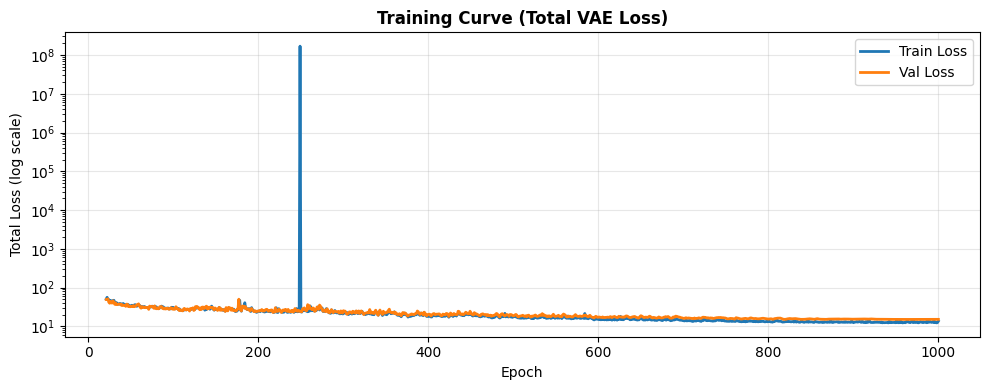

Saved Total Loss curve: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\VAE\VAE_20dim_cholesky_06_loss\vae_loss_curve.png


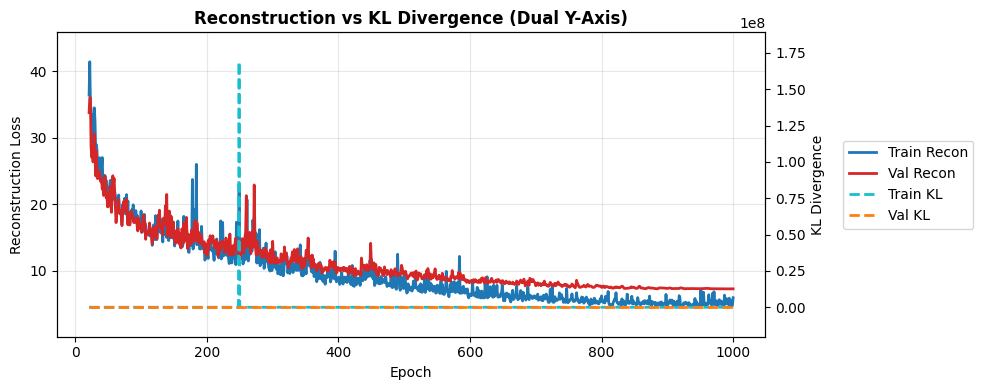

Saved Recon/KL curve: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\VAE\VAE_20dim_cholesky_06_loss\recon_kl_curve.png


In [22]:
# --- PLOTTING DELLE CURVE DI LOSS ---
total_epochs = len(history['train_loss'])
if total_epochs == 0:
    print('No training history to plot.')
else:
    # Preparazione degli assi e degli indici
    epochs_arr = np.arange(1, total_epochs + 1)
    start_idx = 20 if total_epochs > 20 else 0
    ep_plot = epochs_arr[start_idx:]

    # ==========================================
    # GRAFICO 1: VAE Loss Totale
    # ==========================================
    fig1, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(ep_plot, history["train_loss"][start_idx:], label="Train Loss", linewidth=2)
    ax1.plot(ep_plot, history["val_loss"][start_idx:], label="Val Loss", linewidth=2)
    
    ax1.set_title('Training Curve (Total VAE Loss)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_yscale('log')
    ax1.set_ylabel('Total Loss (log scale)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    plt.tight_layout()

    # SALVATAGGIO PRIMA DI MOSTRARE
    loss_curve_path = run_output_dir / 'vae_loss_curve.png'
    fig1.savefig(loss_curve_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig1) # Libera la memoria
    print(f'Saved Total Loss curve: {loss_curve_path}')


    # ==========================================
    # GRAFICO 2: Reconstruction (asse sx) vs KL Divergence (asse dx)
    # ==========================================
    train_recon = np.asarray(history["train_recon"][start_idx:])
    val_recon = np.asarray(history["val_recon"][start_idx:])
    train_kl = np.asarray(history["train_kl"][start_idx:])
    val_kl = np.asarray(history["val_kl"][start_idx:])

    def axis_limits(values_1, values_2, margin_ratio=0.1):
        y_min = float(min(values_1.min(), values_2.min()))
        y_max = float(max(values_1.max(), values_2.max()))
        span = y_max - y_min
        if span == 0:
            span = max(abs(y_max), 1e-6)
        margin = span * margin_ratio
        return y_min - margin, y_max + margin

    fig2, ax_recon = plt.subplots(figsize=(10, 4))
    ax_kl = ax_recon.twinx()

    # Tracciamo le curve
    l1, = ax_recon.plot(ep_plot, train_recon, color="tab:blue", linewidth=2, label="Train Recon")
    l2, = ax_recon.plot(ep_plot, val_recon, color="tab:red", linewidth=2, label="Val Recon")
    l3, = ax_kl.plot(ep_plot, train_kl, color="tab:cyan", linestyle="--", linewidth=2, label="Train KL")
    l4, = ax_kl.plot(ep_plot, val_kl, color="tab:orange", linestyle="--", linewidth=2, label="Val KL")

    # Impostiamo i limiti degli assi dinamicamente
    recon_ymin, recon_ymax = axis_limits(train_recon, val_recon, margin_ratio=0.12)
    kl_ymin, kl_ymax = axis_limits(train_kl, val_kl, margin_ratio=0.12)
    ax_recon.set_ylim(recon_ymin, recon_ymax)
    ax_kl.set_ylim(kl_ymin, kl_ymax)

    # Etichette e colori
    ax_recon.set_xlabel("Epoch")
    ax_recon.set_ylabel("Reconstruction Loss")
    ax_kl.set_ylabel("KL Divergence")
    ax_recon.tick_params(axis="y")
    ax_kl.tick_params(axis="y")
    ax_recon.set_title("Reconstruction vs KL Divergence (Dual Y-Axis)", fontsize=12, fontweight='bold')
    ax_recon.grid(True, alpha=0.3)

    # Legenda combinata
    lines = [l1, l2, l3, l4]
    labels = [line.get_label() for line in lines]
    # Posiziona la legenda fuori dal grafico per evitare che copra le linee
    ax_recon.legend(lines, labels, loc="center left", bbox_to_anchor=(1.1, 0.5))

    fig2.tight_layout()
    
    # SALVATAGGIO PRIMA DI MOSTRARE
    recon_kl_path = run_output_dir / 'recon_kl_curve.png'
    fig2.savefig(recon_kl_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig2) # Libera la memoria
    print(f'Saved Recon/KL curve: {recon_kl_path}')

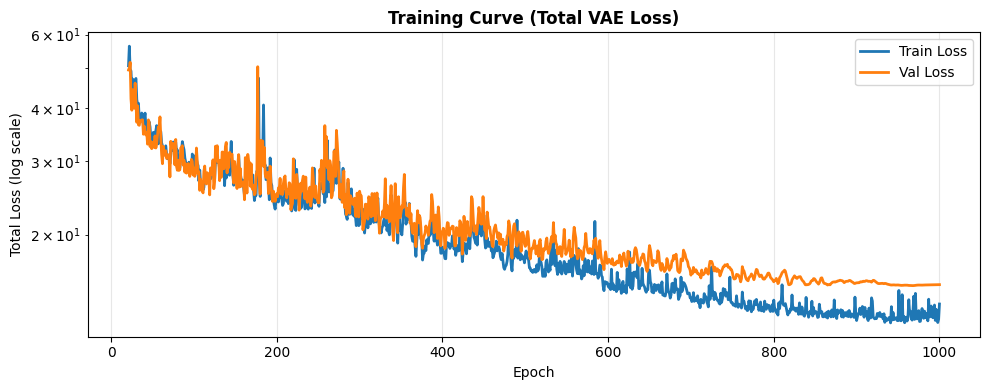

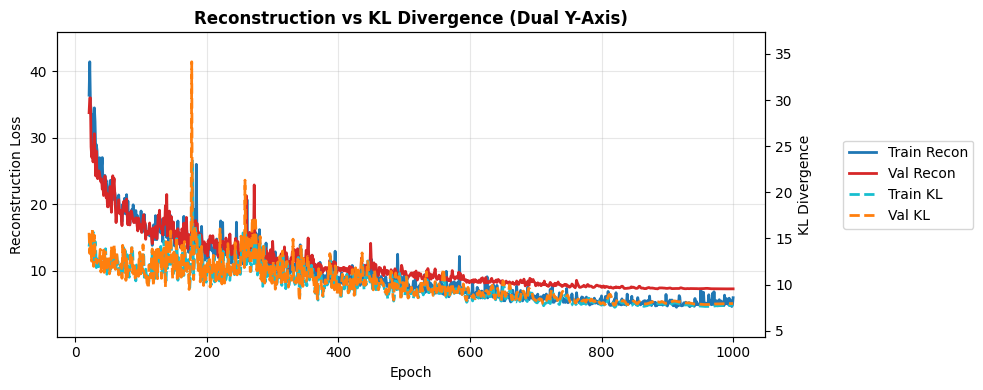

In [29]:
# --- PLOTTING DELLE CURVE DI LOSS ---
total_epochs = len(history['train_loss'])
if total_epochs == 0:
    print('No training history to plot.')
else:
    # 1. DEFINIZIONE DEGLI INDICI DA ESCLUDERE
    # Aggiungi qui tutti gli indici che vuoi rimuovere (es: 249, 250, ecc.)
    indices_to_remove = [248] 
    
    # 2. Creazione della maschera booleana
    mask = np.ones(total_epochs, dtype=bool)
    mask[indices_to_remove] = False
    
    # Applicazione della maschera a tutto lo storico
    # Convertiamo tutto in array per facilitare lo slicing
    history_clean = {k: np.array(v)[mask] for k, v in history.items()}
    epochs_clean = np.arange(1, total_epochs + 1)[mask]

    # Preparazione degli assi (dopo il filtraggio)
    start_idx = 20 if len(epochs_clean) > 20 else 0
    ep_plot = epochs_clean[start_idx:]

    # ==========================================
    # GRAFICO 1: VAE Loss Totale
    # ==========================================
    fig1, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(ep_plot, history_clean["train_loss"][start_idx:], label="Train Loss", linewidth=2)
    ax1.plot(ep_plot, history_clean["val_loss"][start_idx:], label="Val Loss", linewidth=2)
    
    ax1.set_title('Training Curve (Total VAE Loss)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_yscale('log')
    ax1.set_ylabel('Total Loss (log scale)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    plt.tight_layout()

    loss_curve_path = run_output_dir / 'vae_loss_curve.png'
    fig1.savefig(loss_curve_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig1)

    # ==========================================
    # GRAFICO 2: Reconstruction vs KL Divergence
    # ==========================================
    train_recon = history_clean["train_recon"][start_idx:]
    val_recon = history_clean["val_recon"][start_idx:]
    train_kl = history_clean["train_kl"][start_idx:]
    val_kl = history_clean["val_kl"][start_idx:]

    def axis_limits(values_1, values_2, margin_ratio=0.1):
        y_min = float(min(values_1.min(), values_2.min()))
        y_max = float(max(values_1.max(), values_2.max()))
        span = y_max - y_min
        if span == 0: span = max(abs(y_max), 1e-6)
        margin = span * margin_ratio
        return y_min - margin, y_max + margin

    fig2, ax_recon = plt.subplots(figsize=(10, 4))
    ax_kl = ax_recon.twinx()

    l1, = ax_recon.plot(ep_plot, train_recon, color="tab:blue", linewidth=2, label="Train Recon")
    l2, = ax_recon.plot(ep_plot, val_recon, color="tab:red", linewidth=2, label="Val Recon")
    l3, = ax_kl.plot(ep_plot, train_kl, color="tab:cyan", linestyle="--", linewidth=2, label="Train KL")
    l4, = ax_kl.plot(ep_plot, val_kl, color="tab:orange", linestyle="--", linewidth=2, label="Val KL")

    recon_ymin, recon_ymax = axis_limits(train_recon, val_recon, margin_ratio=0.12)
    kl_ymin, kl_ymax = axis_limits(train_kl, val_kl, margin_ratio=0.12)
    ax_recon.set_ylim(recon_ymin, recon_ymax)
    ax_kl.set_ylim(kl_ymin, kl_ymax)

    ax_recon.set_xlabel("Epoch")
    ax_recon.set_ylabel("Reconstruction Loss")
    ax_kl.set_ylabel("KL Divergence")
    ax_recon.set_title("Reconstruction vs KL Divergence (Dual Y-Axis)", fontsize=12, fontweight='bold')
    ax_recon.grid(True, alpha=0.3)

    lines = [l1, l2, l3, l4]
    labels = [line.get_label() for line in lines]
    ax_recon.legend(lines, labels, loc="center left", bbox_to_anchor=(1.1, 0.5))

    fig2.tight_layout()
    recon_kl_path = run_output_dir / 'recon_kl_curve.png'
    fig2.savefig(recon_kl_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig2)

In [11]:
print(model)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=65703, out_features=2048, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=2048, out_features=1024, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
  )
  (fc_mu): Linear(in_features=512, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=512, out_features=20, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=20, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=512, out_features=1024, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=1024, out_features=2048, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=2048, out_features=65703, bias=True)
  )
)


## Step 6: Matrix-Level Reconstruction Visualization
Show the same reconstruction plots used in the PCA notebook: clustered heatmaps and standard heatmaps (original, reconstructed, error).

Original Matrix:
[[1.     0.1809 0.146  0.0234 0.1973]
 [0.1809 1.     0.2591 0.1597 0.3356]
 [0.146  0.2591 1.     0.0816 0.1628]
 [0.0234 0.1597 0.0816 1.     0.1173]
 [0.1973 0.3356 0.1628 0.1173 1.    ]]
Reconstructed Matrix:
[[1.     0.1762 0.1482 0.0142 0.2135]
 [0.1762 1.     0.2476 0.1592 0.337 ]
 [0.1482 0.2476 1.     0.0844 0.1558]
 [0.0142 0.1592 0.0844 1.     0.1922]
 [0.2135 0.337  0.1558 0.1922 1.    ]]
Error Matrix:
[[ 0.     -0.0047  0.0022 -0.0092  0.0162]
 [-0.0047  0.     -0.0114 -0.0006  0.0014]
 [ 0.0022 -0.0114  0.      0.0029 -0.007 ]
 [-0.0092 -0.0006  0.0029  0.      0.0749]
 [ 0.0162  0.0014 -0.007   0.0749  0.    ]]

Sample index: 0
MSE: 0.000139 | MAE: 0.007858 | Frobenius: 4.274683
Error range - Min: -0.099402 | Max: 0.132645


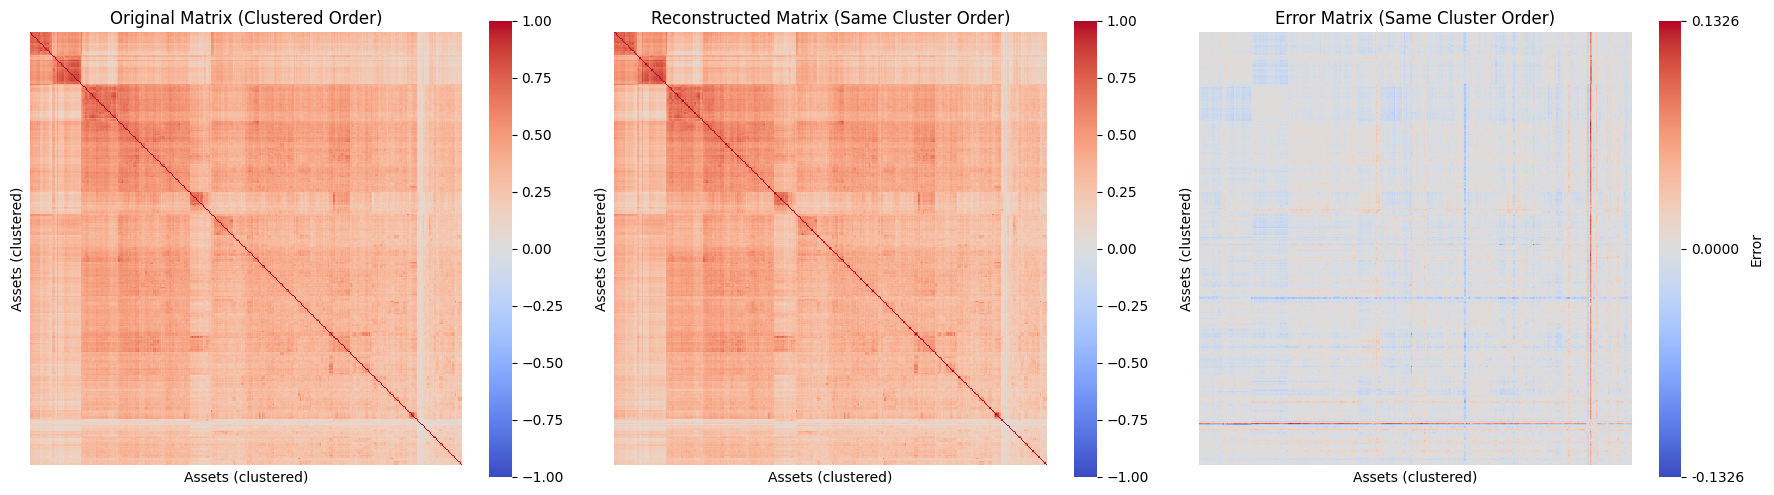

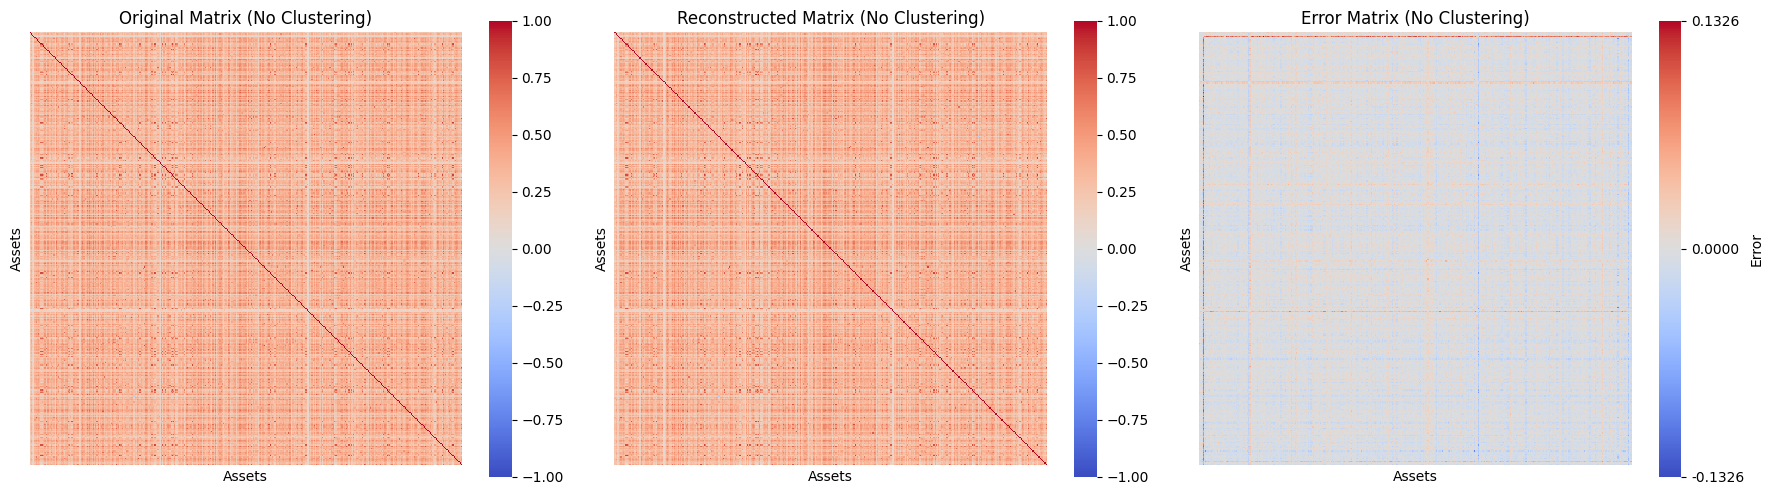

Saved heatmaps for matrix index 0:
 - C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\VAE\VAE_20dim_cholesky_06_loss\heatmaps\idx0\clustered_heatmaps.png
 - C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\VAE\VAE_20dim_cholesky_06_loss\heatmaps\idx0\standard_heatmaps.png


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ricostruzione
recon_out = reconstruct_matrices(model, x_test, n_assets=n_assets, train_mean=train_mean, train_std=train_std, batch_size=BATCH_SIZE)
recon_corr = recon_out['recon_corr']

SAMPLE_IDX = 0

# --- MODIFICA: Assicuriamoci di confrontare con la matrice di correlazione ORIGINALE ---
# test_corr è il tensore originale delle correlazioni del test set (n_test, 362, 362)
# test_chol è quello che la rete ha mangiato, ma noi vogliamo confrontare l'output con test_corr
test_corr_np = test_corr.numpy().astype(np.float32)

if not (0 <= SAMPLE_IDX < test_corr_np.shape[0]):
    raise ValueError(f'SAMPLE_IDX must be in [0, {test_corr_np.shape[0] - 1}]')

orig_mat = test_corr_np[SAMPLE_IDX]
# ------------------------------------------------------------------------------------

recon_mat = recon_corr[SAMPLE_IDX]
err_mat = recon_mat - orig_mat

print(f"Original Matrix:\n{orig_mat[:5, :5]}")  # Print the top-left 5x5 block
print(f"Reconstructed Matrix:\n{recon_mat[:5, :5]}")  
print(f"Error Matrix:\n{err_mat[:5, :5]}")  

mse_sample = float(np.mean((recon_mat - orig_mat) ** 2))
mae_sample = float(np.mean(np.abs(recon_mat - orig_mat)))
fro_sample = float(np.linalg.norm(recon_mat - orig_mat, ord='fro'))

print(f'\nSample index: {SAMPLE_IDX}')
print(f'MSE: {mse_sample:.6f} | MAE: {mae_sample:.6f} | Frobenius: {fro_sample:.6f}')
print(f'Error range - Min: {err_mat.min():.6f} | Max: {err_mat.max():.6f}')

heatmap_base_dir = run_output_dir / 'heatmaps'
heatmap_base_dir.mkdir(parents=True, exist_ok=True)
heatmap_dir = heatmap_base_dir / f'idx{SAMPLE_IDX}'
heatmap_dir.mkdir(parents=True, exist_ok=True)

shared_cmap = 'coolwarm'
err_abs_max = float(np.max(np.abs(err_mat)))
if err_abs_max == 0:
    err_abs_max = 1e-6

# --- HEATMAP CLUSTERIZZATE ---
# Build a single cluster ordering from the original matrix and reuse it for all three panels.
cluster_ref = sns.clustermap(
    orig_mat,
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
row_order = cluster_ref.dendrogram_row.reordered_ind
col_order = cluster_ref.dendrogram_col.reordered_ind
plt.close(cluster_ref.fig)

orig_mat_clustered = orig_mat[np.ix_(row_order, col_order)]
recon_mat_clustered = recon_mat[np.ix_(row_order, col_order)]
err_mat_clustered = err_mat[np.ix_(row_order, col_order)]

fig_cluster, axes_cluster = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    orig_mat_clustered,
    ax=axes_cluster[0],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
)
axes_cluster[0].set_title('Original Matrix (Clustered Order)')

sns.heatmap(
    recon_mat_clustered,
    ax=axes_cluster[1],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
)
axes_cluster[1].set_title('Reconstructed Matrix (Same Cluster Order)')

hm_cluster_err = sns.heatmap(
    err_mat_clustered,
    ax=axes_cluster[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes_cluster[2].set_title('Error Matrix (Same Cluster Order)')

cbar_cluster = hm_cluster_err.collections[0].colorbar
cbar_cluster.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_cluster.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes_cluster:
    ax.set_xlabel('Assets (clustered)')
    ax.set_ylabel('Assets (clustered)')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path_cluster_all = heatmap_dir / 'clustered_heatmaps.png'
fig_cluster.savefig(path_cluster_all, dpi=150, bbox_inches='tight')
plt.show()

# --- HEATMAP STANDARD ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_mat, ax=axes[0], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[0].set_title('Original Matrix (No Clustering)')

sns.heatmap(recon_mat, ax=axes[1], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[1].set_title('Reconstructed Matrix (No Clustering)')

hm = sns.heatmap(
    err_mat,
    ax=axes[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes[2].set_title('Error Matrix (No Clustering)')

cbar_std = hm.collections[0].colorbar
cbar_std.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_std.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes:
    ax.set_xlabel('Assets')
    ax.set_ylabel('Assets')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path_standard = heatmap_dir / 'standard_heatmaps.png'
fig.savefig(path_standard, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved heatmaps for matrix index {SAMPLE_IDX}:')
print(f' - {path_cluster_all}')
print(f' - {path_standard}')

## Step 7: Reconstruction Error Statistics
Compute error statistics on train/test for both reconstructed matrices and input vectors.

In [13]:
# --- 1. PREPARAZIONE DELLE MATRICI ORIGINALI ---
# Assicuriamoci di usare i tensori di CORRELAZIONE, non quelli di Cholesky
train_corr_np = train_corr.numpy().astype(np.float32)
val_corr_np = val_corr.numpy().astype(np.float32)
test_corr_np = test_corr.numpy().astype(np.float32)

recon_out_test = reconstruct_matrices(model, x_test, n_assets=n_assets, train_mean=train_mean, train_std=train_std, batch_size=BATCH_SIZE)
recon_corr_test = recon_out_test['recon_corr']
z_points_test = recon_out_test['latent_points']

recon_out_train = reconstruct_matrices(model, x_train, n_assets=n_assets, train_mean=train_mean, train_std=train_std, batch_size=BATCH_SIZE)
recon_corr_train = recon_out_train['recon_corr']
z_points_train = recon_out_train['latent_points']

recon_out_val = reconstruct_matrices(model, x_val, n_assets=n_assets, train_mean=train_mean, train_std=train_std, batch_size=BATCH_SIZE)
recon_corr_val = recon_out_val['recon_corr']
z_points_val = recon_out_val['latent_points']

errors_df_test_matrix, errors_stats_test_matrix = reconstruction_errors(test_corr_np, recon_corr_test)
errors_df_train_matrix, errors_stats_train_matrix = reconstruction_errors(train_corr_np, recon_corr_train)
errors_df_val_matrix, errors_stats_val_matrix = reconstruction_errors(val_corr_np, recon_corr_val)

print('Reconstruction error statistics (Train Set, matrices):')
display(errors_stats_train_matrix)
print('\nReconstruction error statistics (Validation Set, matrices):')
display(errors_stats_val_matrix)
print('\nReconstruction error statistics (Test Set, matrices):')
display(errors_stats_test_matrix)

Reconstruction error statistics (Train Set, matrices):


,mean,std,min,median,max
MSE,0.000087,0.000077,0.000014,0.000065,0.000762
MAE,0.006436,0.002664,0.002860,0.005995,0.021751
Frobenius,3.162532,1.177206,1.358025,2.908820,9.993035



Reconstruction error statistics (Validation Set, matrices):


,mean,std,min,median,max
MSE,0.000173,0.000213,0.000020,0.000105,0.001256
MAE,0.008953,0.005042,0.003167,0.007267,0.031339
Frobenius,4.283456,2.084007,1.612197,3.716034,12.829167



Reconstruction error statistics (Test Set, matrices):


,mean,std,min,median,max
MSE,0.000155,0.000110,0.000040,0.000122,0.000587
MAE,0.008593,0.003151,0.003359,0.008069,0.017029
Frobenius,4.281287,1.425272,2.283888,3.992239,8.767473


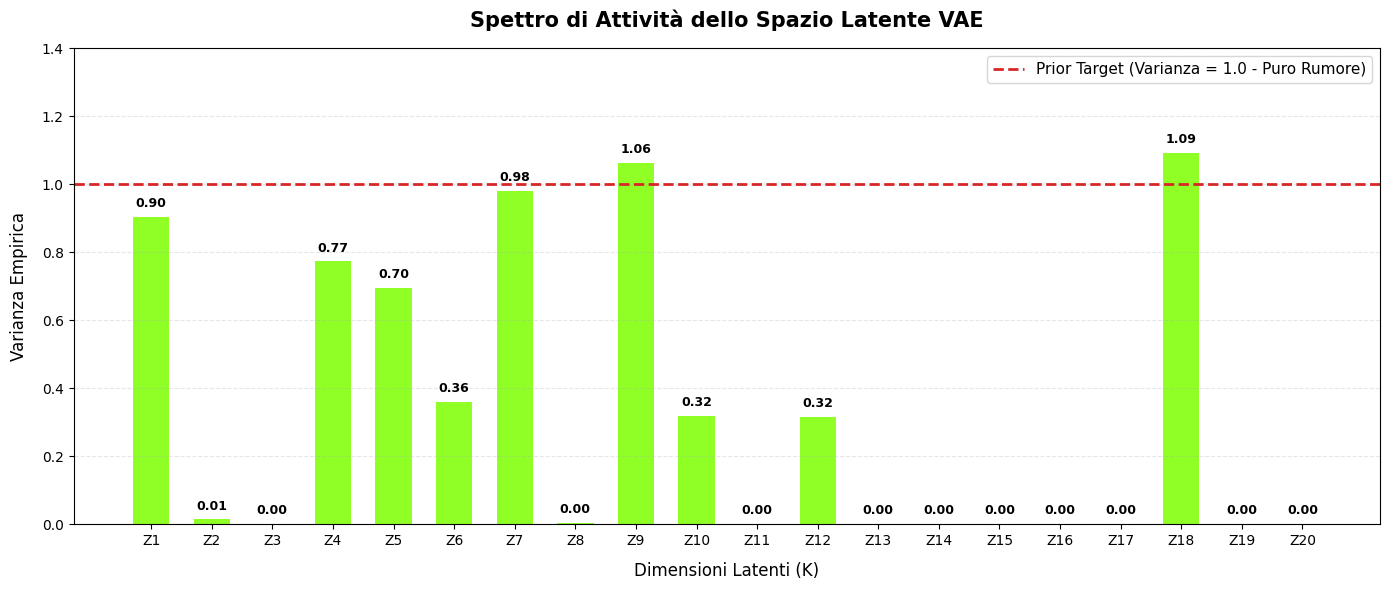

Grafico dello spettro delle varianze salvato in: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\VAE\VAE_20dim_cholesky_06_loss\plots\latent_dimensions_variance_spectrum.png


In [25]:
# Assicuriamoci che la directory esista
plots_dir = run_output_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

def plot_all_latents_variance(z_train, save_path):
    """
    Genera un grafico a barre che mostra la varianza di ciascuna dimensione latente,
    evidenziando visivamente quali canali sono attivi e quali sono spenti.
    """
    latent_dim = z_train.shape[1]
    
    # 1. Calcoliamo la varianza di ogni colonna (asse latente)
    variances = np.var(z_train, axis=0)
    
    # Creiamo gli identificativi per l'asse X (Z1, Z2, ..., Z20)
    labels = [f"Z{i+1}" for i in range(latent_dim)]
    
    # 2. Configurazione della figura
    plt.figure(figsize=(14, 6))
    
    # Definiamo i colori delle barre
    colors = ['#7BFF00' for v in variances]
    
    # Disegniamo le barre
    bars = plt.bar(labels, variances, color=colors, edgecolor='none', alpha=0.85, width=0.6)
    
    # 3. Linea di riferimento a 1.0 (Prior Gaussiana del VAE)
    plt.axhline(y=1.0, color='#D62728', linestyle='--', linewidth=2, 
                label='Prior Target (Varianza = 1.0 - Puro Rumore)')
    
    # Aggiungiamo i valori numerici sopra ogni barra per una lettura immediata
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.02, 
                 f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
                 
    # 4. Formattazione estetica del grafico
    plt.title('Spettro di Attività dello Spazio Latente VAE', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel('Dimensioni Latenti (K)', fontsize=12, labelpad=10)
    plt.ylabel('Varianza Empirica', fontsize=12, labelpad=10)
    
    # Aumentiamo leggermente il limite superiore dell'asse Y (fino a 1.4) 
    # per lasciare spazio alla legenda in alto a destra senza sovrapposizioni
    plt.ylim(0, max(max(variances) + 0.2, 1.4)) 
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    # MODIFICA: Spostata la legenda in alto a destra
    plt.legend(loc='upper right', fontsize=11)
    
    # Salvataggio e mostra del grafico
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print(f"Grafico dello spettro delle varianze salvato in: {save_path}")

# ==========================================
# ESECUZIONE
# ==========================================
variance_spectrum_file = plots_dir / "latent_dimensions_variance_spectrum.png"
plot_all_latents_variance(z_points_train, save_path=variance_spectrum_file)


--- ANALISI DELLO SPAZIO LATENTE (K=20) ---
Varianze per ogni dimensione (ordinate):
  Z18: 1.0920
  Z9: 1.0642
  Z7: 0.9811
  Z1: 0.9048
  Z4: 0.7732
  Z5: 0.6951
  Z6: 0.3597
  Z10: 0.3198
  Z12: 0.3155
  Z2: 0.0146
  Z8: 0.0035
  Z13: 0.0026
  Z3: 0.0021
  Z16: 0.0014
  Z11: 0.0013
  Z17: 0.0012
  Z15: 0.0012
  Z20: 0.0011
  Z19: 0.0010
  Z14: 0.0010

Dimensioni selezionate per il plot (Top 4): Z18, Z9, Z7, Z1


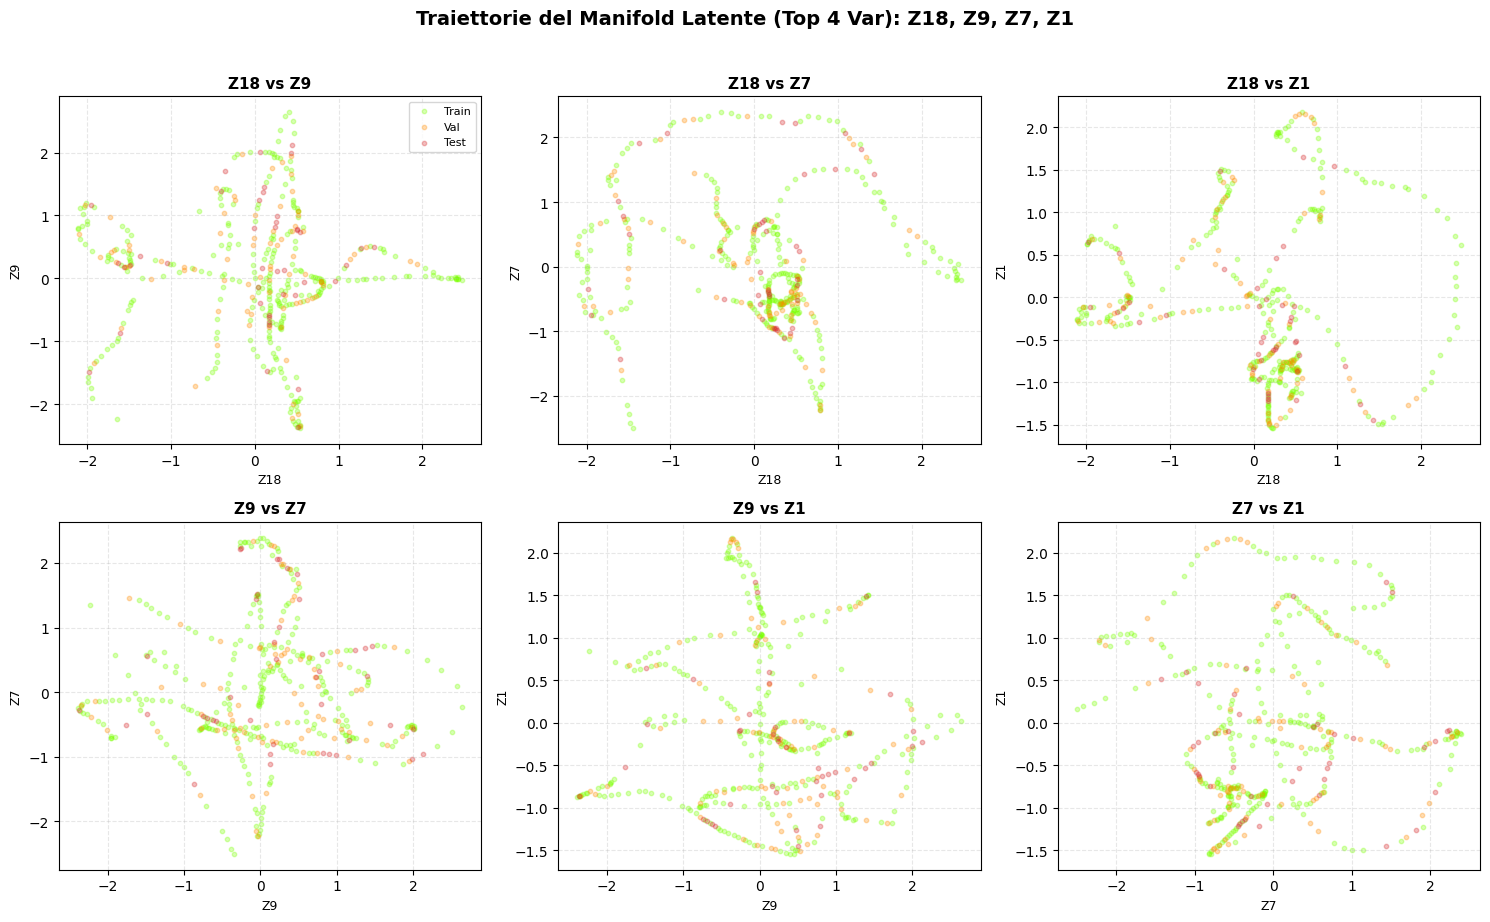

Grafico salvato in: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\VAE\VAE_20dim_cholesky_06_loss\plots\latent_space_top_active_2d.png


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

def plot_active_latent_dimensions(z_train, z_val, z_test, save_path, top_n=4):
    """
    Seleziona le dimensioni latenti con varianza maggiore e ne plotta 
    le combinazioni bivariate per visualizzare la struttura del manifold.
    """
    # Conversione in numpy array di sicurezza
    z_train = np.array(z_train)
    z_val = np.array(z_val)
    z_test = np.array(z_test)
    
    latent_dim = z_train.shape[1]
    
    # 1. Calcolo varianza e ordinamento esplicito (Robustezza massima)
    variances = np.var(z_train, axis=0)
    # Creiamo coppie (indice, varianza) e ordiniamo per varianza decrescente
    indexed_variances = [(i, var) for i, var in enumerate(variances)]
    indexed_variances.sort(key=lambda x: x[1], reverse=True)
    
    top_indices = [x[0] for x in indexed_variances[:top_n]]
    
    print(f"\n--- ANALISI DELLO SPAZIO LATENTE (K={latent_dim}) ---")
    print("Varianze per ogni dimensione (ordinate):")
    for d, var in indexed_variances:
        print(f"  Z{d+1}: {var:.4f}")
    
    print(f"\nDimensioni selezionate per il plot (Top {top_n}): " + 
          ", ".join([f"Z{idx+1}" for idx in top_indices]))
    
    # 2. Generazione combinazioni bivariate
    projections = list(itertools.combinations(top_indices, 2))
    n_plots = len(projections)
    
    # Griglia dinamica (max 3 colonne)
    n_cols = min(3, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), squeeze=False)
    axes = axes.flatten()
    
    for i, (idx_x, idx_y) in enumerate(projections):
        ax = axes[i]
        xlabel, ylabel = f'Z{idx_x + 1}', f'Z{idx_y + 1}'
        
        # Plot dei dataset (Train, Val, Test)
        ax.scatter(z_train[:, idx_x], z_train[:, idx_y], c="#7BFF00", label='Train', alpha=0.3, s=10)
        ax.scatter(z_val[:, idx_x], z_val[:, idx_y], c='#FF8C00', label='Val', alpha=0.3, s=10)
        ax.scatter(z_test[:, idx_x], z_test[:, idx_y], c='#D62728', label='Test', alpha=0.3, s=10)
        
        ax.set_title(f'{xlabel} vs {ylabel}', fontsize=11, fontweight='bold')
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.3)
    
    # Rimuovi eventuali subplot vuoti
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])
        
    axes[0].legend(loc='best', fontsize=8)
    
    top_labels = ", ".join([f"Z{idx+1}" for idx in top_indices])
    fig.suptitle(f'Traiettorie del Manifold Latente (Top {top_n} Var): {top_labels}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Grafico salvato in: {save_path}")

# ==========================================
# ESECUZIONE
# ==========================================
if LATENT_DIM >= 4:
    plots_dir = run_output_dir / "plots"
    plots_dir.mkdir(parents=True, exist_ok=True)
    active_projections_file = plots_dir / "latent_space_top_active_2d.png"
    
    plot_active_latent_dimensions(
        z_points_train, z_points_val, z_points_test, 
        save_path=active_projections_file, top_n=4
    )


--- ANALISI DELLO SPAZIO LATENTE (K=20) ---

Varianza empirica dei MU:
Z14 | Var(mu) = 0.001015
Z19 | Var(mu) = 0.001048
Z20 | Var(mu) = 0.001135
Z15 | Var(mu) = 0.001179
Z17 | Var(mu) = 0.001189
Z11 | Var(mu) = 0.001255
Z16 | Var(mu) = 0.001388
Z03 | Var(mu) = 0.002069
Z13 | Var(mu) = 0.002596
Z08 | Var(mu) = 0.003455
Z02 | Var(mu) = 0.014647
Z12 | Var(mu) = 0.315474
Z10 | Var(mu) = 0.319822
Z06 | Var(mu) = 0.359711
Z05 | Var(mu) = 0.695108
Z04 | Var(mu) = 0.773157
Z01 | Var(mu) = 0.904810
Z07 | Var(mu) = 0.981101
Z09 | Var(mu) = 1.064170
Z18 | Var(mu) = 1.091975

Dimensioni più inattive selezionate:
Z14 | Var(mu) = 0.001015
Z19 | Var(mu) = 0.001048
Z20 | Var(mu) = 0.001135
Z15 | Var(mu) = 0.001179


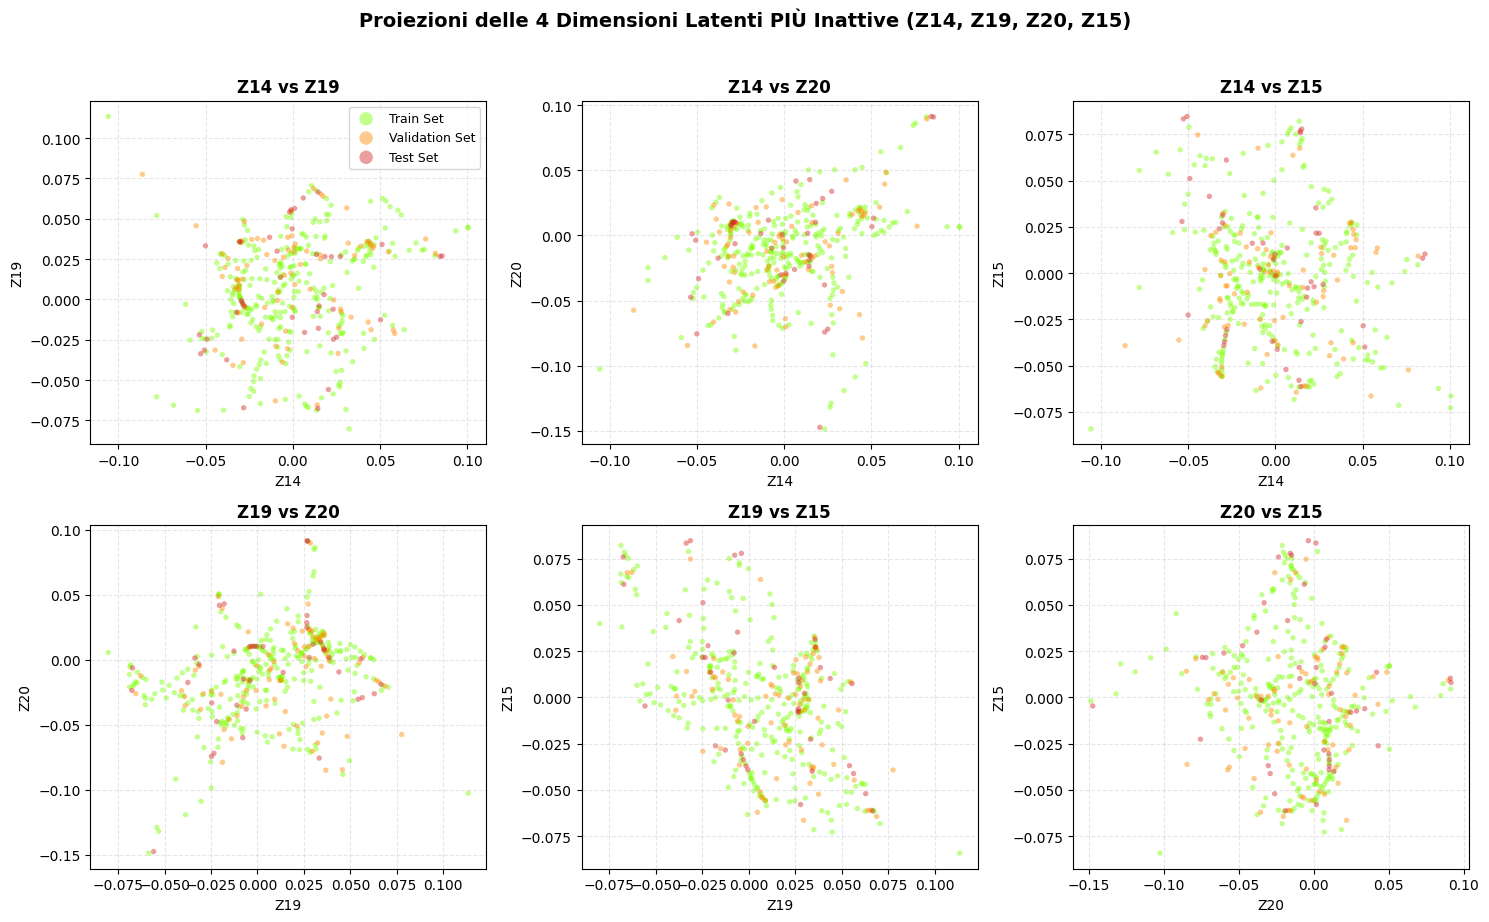


Grafico salvato in:
C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\VAE\VAE_20dim_cholesky_06_loss\plots\latent_space_bottom_inactive_2d.png


In [16]:
if LATENT_DIM >= 4:
    import itertools
    import numpy as np
    import matplotlib.pyplot as plt

    # Assicuriamoci che la directory esista
    plots_dir = run_output_dir / "plots"
    plots_dir.mkdir(parents=True, exist_ok=True)

    def plot_inactive_latent_dimensions(
        z_train,
        z_val,
        z_test,
        save_path,
        bottom_n=4
    ):
        """
        Analizza i MU dell'encoder.

        Una dimensione latente è considerata inattiva quando:

            Var(mu_i) ≈ 0

        cioè quando il suo valore cambia pochissimo tra i campioni
        e quindi trasporta poca informazione.
        """

        latent_dim = z_train.shape[1]

        # ==========================================
        # VARIANZA DEI MU SUL TRAIN SET
        # ==========================================
        variances = np.var(z_train, axis=0)

        # Le dimensioni meno informative sono quelle
        # con varianza più piccola
        bottom_indices = np.argsort(variances)[:bottom_n]

        print(f"\n--- ANALISI DELLO SPAZIO LATENTE (K={latent_dim}) ---")

        print("\nVarianza empirica dei MU:")

        sorted_idx = np.argsort(variances)

        for idx in sorted_idx:
            print(
                f"Z{idx+1:02d} | Var(mu) = {variances[idx]:.6f}"
            )

        print("\nDimensioni più inattive selezionate:")

        for idx in bottom_indices:
            print(
                f"Z{idx+1} | Var(mu) = {variances[idx]:.6f}"
            )

        # ==========================================
        # GENERAZIONE DELLE PROIEZIONI 2D
        # ==========================================
        projections = list(itertools.combinations(bottom_indices, 2))

        n_plots = len(projections)

        n_cols = min(3, n_plots)
        n_rows = (n_plots + n_cols - 1) // n_cols

        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(5 * n_cols, 4.5 * n_rows),
            squeeze=False
        )

        axes = axes.flatten()

        for i, (idx_x, idx_y) in enumerate(projections):

            ax = axes[i]

            xlabel = f"Z{idx_x + 1}"
            ylabel = f"Z{idx_y + 1}"

            ax.scatter(
                z_train[:, idx_x],
                z_train[:, idx_y],
                c="#7BFF00",
                label="Train Set",
                alpha=0.45,
                s=15,
                edgecolors="none"
            )

            ax.scatter(
                z_val[:, idx_x],
                z_val[:, idx_y],
                c="#FF8C00",
                label="Validation Set",
                alpha=0.45,
                s=15,
                edgecolors="none"
            )

            ax.scatter(
                z_test[:, idx_x],
                z_test[:, idx_y],
                c="#D62728",
                label="Test Set",
                alpha=0.45,
                s=15,
                edgecolors="none"
            )

            ax.set_title(
                f"{xlabel} vs {ylabel}",
                fontsize=12,
                fontweight="bold"
            )

            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)

            ax.grid(True, linestyle="--", alpha=0.3)

        # Elimina eventuali subplot vuoti
        for j in range(n_plots, len(axes)):
            fig.delaxes(axes[j])

        axes[0].legend(
            loc="best",
            fontsize=9,
            markerscale=2.5
        )

        inactive_labels = ", ".join(
            [f"Z{idx+1}" for idx in bottom_indices]
        )

        fig.suptitle(
            f"Proiezioni delle {bottom_n} Dimensioni Latenti PIÙ Inattive ({inactive_labels})",
            fontsize=14,
            fontweight="bold",
            y=1.02
        )

        plt.tight_layout()

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

        print(f"\nGrafico salvato in:\n{save_path}")

        return bottom_indices, variances

    # ==========================================
    # ESECUZIONE
    # ==========================================

    inactive_projections_file = (
        plots_dir / "latent_space_bottom_inactive_2d.png"
    )

    inactive_dims, variances = plot_inactive_latent_dimensions(
        z_points_train,
        z_points_val,
        z_points_test,
        save_path=inactive_projections_file,
        bottom_n=4
    )

In [17]:
if LATENT_DIM == 3:
    # Assicuriamoci che la directory esista
    plots_dir = run_output_dir / "plots"
    plots_dir.mkdir(parents=True, exist_ok=True)

    # ==========================================
    # 1. FUNZIONE PER LE PROIEZIONI 2D
    # ==========================================
    def plot_latent_space_2d_projections(z_train, z_val, z_test, save_path):
        # Creazione di una figura con 3 subplot affiancati (1 riga, 3 colonne)
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        
        # Definizione delle coppie di assi da plottare: (indice_x, indice_y, label_x, label_y)
        projections = [
            (0, 1, 'Z1', 'Z2'),
            (0, 2, 'Z1', 'Z3'),
            (1, 2, 'Z2', 'Z3')
        ]
        
        for ax, (idx_x, idx_y, xlabel, ylabel) in zip(axes, projections):
            # 1. Train Set (Sfondo)
            ax.scatter(z_train[:, idx_x], z_train[:, idx_y], 
                    c="#7BFF00", label='Train Set', alpha=0.5, s=20, edgecolors='none')
            
            # 2. Validation Set (Livello intermedio)
            ax.scatter(z_val[:, idx_x], z_val[:, idx_y], 
                    c='#FF8C00', label='Validation Set', alpha=0.5, s=20, edgecolors='none')
            
            # 3. Test Set (Primo piano)
            ax.scatter(z_test[:, idx_x], z_test[:, idx_y], 
                    c='#D62728', label='Test Set', alpha=0.5, s=20, edgecolors='none')
            
            # Formattazione rigorosa degli assi
            ax.set_title(f'Proiezione {xlabel} vs {ylabel}', fontsize=14, fontweight='bold')
            ax.set_xlabel(xlabel, fontsize=12)
            ax.set_ylabel(ylabel, fontsize=12)
            ax.grid(True, linestyle='--', alpha=0.4)
            
            # Evita che i grafici abbiano scale diverse per mantenere le proporzioni geometriche
            ax.axis('equal') 

        # Aggiunge un'unica legenda globale al primo subplot
        axes[0].legend(loc='best', fontsize=10, markerscale=3)
        
        # Titolo globale della figura
        fig.suptitle('Mappatura Bivariata dello Spazio Latente VAE', fontsize=16, fontweight='bold', y=1.05)
        
        # Ottimizzazione del layout e salvataggio
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        
        print(f"Scatter plot 2D (proiezioni) salvato in: {save_path}")


    # ==========================================
    # 2. FUNZIONE PER IL GRAFICO 3D
    # ==========================================
    def plot_latent_space_3d(z_train, z_val, z_test, save_path):
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')

        # Train Set
        ax.scatter(z_train[:, 0], z_train[:, 1], z_train[:, 2], 
                c="#7BFF00", label='Train Set', alpha=0.5, s=20, edgecolors='none')

        # Validation Set
        ax.scatter(z_val[:, 0], z_val[:, 1], z_val[:, 2], 
                c='#FF8C00', label='Validation Set', alpha=0.5, s=20, edgecolors='none')

        # Test Set
        ax.scatter(z_test[:, 0], z_test[:, 1], z_test[:, 2], 
                c='#D62728', label='Test Set', alpha=0.5, s=20, edgecolors='none')

        # Formattazione degli assi
        ax.set_title('Mappatura Tridimensionale dello Spazio Latente VAE (K=3)', fontsize=16, pad=20, fontweight='bold')
        ax.set_xlabel('Z1', fontsize=12, labelpad=10)
        ax.set_ylabel('Z2', fontsize=12, labelpad=10)
        ax.set_zlabel('Z3', fontsize=12, labelpad=10)
        
        # Configurazione della legenda
        ax.legend(loc='upper right', fontsize=12, markerscale=3)

        # Salvataggio e visualizzazione
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        
        print(f"Scatter plot 3D salvato in: {save_path}")


    # ==========================================
    # 3. ESECUZIONE DELLE FUNZIONI
    # ==========================================
    # Generazione dei 3 scatter plot 2D
    projections_file = plots_dir / "latent_space_projections_2d.png"
    plot_latent_space_2d_projections(z_points_train, z_points_val, z_points_test, save_path=projections_file)

    # Generazione dello scatter plot 3D
    plot_3d_file = plots_dir / "latent_space_scatter_3d.png"
    plot_latent_space_3d(z_points_train, z_points_val, z_points_test, save_path=plot_3d_file)

In [18]:
results_path = run_output_dir / 'run_results.json'

recon_stats_payload = None
if 'errors_stats_test_matrix' in globals():
    recon_stats_payload = {
        'test_matrix': errors_stats_test_matrix.astype(float).to_dict(orient='index'),
        'train_matrix': errors_stats_train_matrix.astype(float).to_dict(orient='index'),
    }

scheduler_key = str(SCHEDULER_NAME).strip().lower()

if scheduler_key == 'none':
    scheduler_payload = None
elif scheduler_key == 'cosine':
    scheduler_payload = {
        'key': scheduler_key,
        'T_max': int(COSINE_T_MAX),
        'eta_min': float(COSINE_ETA_MIN),
    }

resumed = bool(RESUME_TRAINING)
if resumed:
    resume_info = {
        'source_model_path': str(resume_source_path) if resume_source_path is not None else None,
        'initial_best_val': float(resume_initial_val) if resume_initial_val is not None else None,
    }
else:
    resume_info = None

hidden_dims_info = [int(x) for x in HIDDEN_DIMS]

results_payload = {
    'run': RUN,
    'seed': int(SEED),
    'dataset_info': {
        'dataset_name': DATASET_NAME,
        'n_matrices': int(n_matrices),
        'n_assets': int(n_assets),
        'n_features': int(n_features),
        'splits': {
            'train_size': int(n_train),
            'val_size': int(n_val),
            'test_size': int(n_test),
            'val_fraction': round(float(VAL_FRACTION), 2),
            'test_fraction': round(float(TEST_FRACTION), 2),
        },
    },
    'model': {
        'model_type': MODEL_TYPE,
        'latent_dim': int(LATENT_DIM),
        'hidden_dims': hidden_dims_info,
        'epochs': int(EPOCHS),
        'batch_size': int(BATCH_SIZE),
        'lr': float(LR),
        'weight_decay': float(WEIGHT_DECAY),
        'beta': float(BETA) if 'BETA' in globals() else 1.0, # VAE ADDITION: salvataggio del beta
        'scheduler': scheduler_payload,
        'best_val_loss': float(best_val) if 'best_val' in globals() else None,
        'resume': resume_info,
    },
    'artifacts': {
        'best_model_path': str(best_model_path) if 'best_model_path' in globals() else None,
        'training_curve_path': str(loss_curve_path) if 'loss_curve_path' in globals() else None,
    },
    'metrics': {
        'reconstruction_stats': recon_stats_payload,
    },
    'loss_history': {
        # Loss Totale e Learning Rate
        'train_loss': [float(x) for x in history['train_loss']],
        'val_loss': [float(x) for x in history['val_loss']],
        'lr': [float(x) for x in history['lr']] if 'lr' in history else None,
        
        # VAE ADDITION: Componenti separate della Loss
        'train_recon': [float(x) for x in history['train_recon']] if 'train_recon' in history else None,
        'val_recon': [float(x) for x in history['val_recon']] if 'val_recon' in history else None,
        'train_kl': [float(x) for x in history['train_kl']] if 'train_kl' in history else None,
        'val_kl': [float(x) for x in history['val_kl']] if 'val_kl' in history else None,
    },
}

with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results_payload, f, indent=4)

print(f'Saved results: {results_path}')


# 1. Assicurati che siano tensori PyTorch 
# (se hai seguito il codice precedente, train_mean e train_std lo sono già)
mean_tensor = train_mean if isinstance(train_mean, torch.Tensor) else torch.from_numpy(train_mean)
std_tensor = train_std if isinstance(train_std, torch.Tensor) else torch.from_numpy(train_std)

# 2. Definisci i percorsi dei file
mean_path = Path(run_output_dir, 'train_mean.pt')
std_path = Path(run_output_dir, 'train_std.pt')

# 3. Salva i file su disco
torch.save(mean_tensor, mean_path)
torch.save(std_tensor, std_path)

print(f"\n--- Salvataggio Statistiche (.pt) ---")
print(f"Media salvata in: {mean_path}")
print(f"Deviazione standard salvata in: {std_path}")

Saved results: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\VAE\VAE_20dim_cholesky_06_loss\run_results.json

--- Salvataggio Statistiche (.pt) ---
Media salvata in: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\VAE\VAE_20dim_cholesky_06_loss\train_mean.pt
Deviazione standard salvata in: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w724_s10\VAE\VAE_20dim_cholesky_06_loss\train_std.pt
